<a href="https://colab.research.google.com/github/kshitijpoudyal/Amazon-Review-Tracker/blob/main/Copy_of_Course_Project_4_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Course Project 4: Computer Vision**
* In this project, you will learn how to train a convolutional neural network to classify food images.
* This project was adapted from Dr. Hung-Yi Lee's Machine Learning course (Spring 2022). Source: https://speech.ee.ntu.edu.tw/~hylee/ml/2022-spring.php

# 0. GPU Enable
* Make sure the GPU is enable in the colab.
* If the output from the below code block is not ``cuda``, the GPU is not enabled.
* To use GPU, go to ``Runtime`` -> ``change runtime type`` -> ``T4 GPU``.

In [ ]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Mount Your Google Drive to Save the Training Data and Best Model
* Since the training time of this project will be longer than other projects, it is highly recommended to save the best-performing model to your Google Drive so that you can access it later.
* Create a folder in your Google Drive to store the model parameters
* You can edit the folder path to a location that you prefer

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# you may edit this model_path to a location that you prefer
model_path = '/content/drive/MyDrive/CourseProject4/Models'
os.makedirs(model_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Get Data (Only Run One Time)
* The follow code will download a zip file to your Google Drive
* You only need to run the following block **one time**, meaning that, if you already run this block before and have the zip file in your Google Drive, you don't need to run this block anymore.

In [ ]:
# create a dataset path to save the dataset
data_path = '/content/drive/MyDrive/CourseProject4/Data'
os.makedirs(data_path, exist_ok=True)

# download the zip file into your drive
!pip install gdown --upgrade
!gdown https://drive.google.com/file/d/1TIzsnhy5D15blTlgVWZVCYXnJ1dEJPLv/view?usp=sharing --output "{data_path}/food11.zip"

# upzip the images into your Google Drive so you don't need to upzip it everytime you run this Colab note.
!unzip -q "{data_path}/food11.zip" -d "{data_path}"

Downloading...
From (original): https://drive.google.com/uc?id=1TIzsnhy5D15blTlgVWZVCYXnJ1dEJPLv
From (redirected): https://drive.google.com/uc?id=1TIzsnhy5D15blTlgVWZVCYXnJ1dEJPLv&confirm=t&uuid=5ed66718-8cd0-4f94-a8c0-a2a8e6c5e790
To: /content/drive/MyDrive/CourseProject4/Data/food11.zip
100% 956M/956M [00:13<00:00, 71.9MB/s]
replace /content/drive/MyDrive/CourseProject4/Data/food11/test/0_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Import Packages

In [ ]:
# Import necessary packages.
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
# "ConcatDataset" and "Subset" are possibly useful when doing semi-supervised learning.
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
# This is for the progress bar.
from tqdm.auto import tqdm
import random
import matplotlib.pyplot as plt
import torchvision

In [ ]:
myseed = 6666  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms
Torchvision provides lots of useful utilities for image preprocessing, data *wrapping* as well as data augmentation.

Please refer to PyTorch official website for details about different transforms.

In [ ]:
# test_tfm is for testing data augmentation. Normally, We don't need augmentations in testing and validation.
# Here, we just resize the image and transform it into Tensor.
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    normalize
])

test_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])


# Datasets
The data is labelled by the name, so we load images and label while calling '__getitem__'

In [ ]:
class FoodDataset(Dataset):

    def __init__(self, path, tfm, files = None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([os.path.join(path,x) for x in os.listdir(path) if x.endswith(".jpg")])
        if files != None:
            self.files = files

        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)

        try:
            label = int(fname.split("/")[-1].split("_")[0])
        except:
            label = -1 # test has no label

        return im, label

# Display Sample Images

## Load Data for Display

In [ ]:
# Specify the training, valid, and testing dataset path
train_path = f"{data_path}/food11/train"
valid_path = f"{data_path}/food11/valid"
test_path = f"{data_path}/food11/test"

# original-like deterministic view
original_set = FoodDataset(train_path, tfm=test_tfm)
original_loader = DataLoader(original_set, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# augmented training view
transform_set = FoodDataset(train_path, tfm=train_tfm)
transform_loader = DataLoader(transform_set, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# functions to show an image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


## Display the Original Images

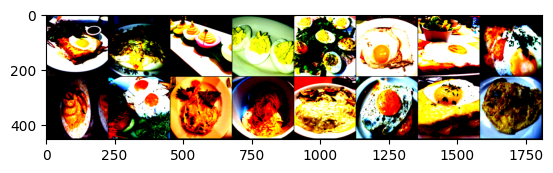

In [ ]:
# get some random training images
dataiter = iter(original_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

## Display the images after Transforms defined in `train_tfm`

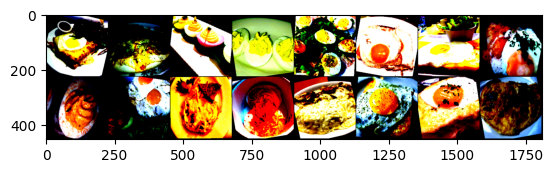

In [ ]:
# get some random training images
dataiter = iter(transform_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

# Model

In [ ]:
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Upgraded to ResNet50 for better accuracy
        self.model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, 11)

    def forward(self, x):
        return self.model(x)

# Dataloader

In [ ]:
batch_size = 32  # use 32 first for 224x224, increase later if GPU allows

train_set = FoodDataset(train_path, tfm=train_tfm)
train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_set = FoodDataset(valid_path, tfm=test_tfm)
valid_loader = DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Configuration

In [ ]:
stale = 0
best_acc = 0

model = Classifier().to(device)

# Stage 1: freeze backbone, train classifier only
for param in model.model.parameters():
    param.requires_grad = False

# keep final layer trainable
for param in model.model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

continuous_training = False

if continuous_training:
    checkpoint = torch.load(f"{model_path}/CP4_best.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

n_epochs = 40
patience = 8
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


# Start Training

In [ ]:
# Training Loop
for epoch in range(n_epochs):

    # unfreeze backbone after 5 epochs
    if epoch == 5:
        print("Unfreezing backbone for fine-tuning...")

        # keep final layer trainable
        for param in model.model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2
        )

    # ---------- Training ----------
    model.train()
    train_loss = []
    train_accs = []

    for batch in tqdm(train_loader):
        imgs, labels = batch
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = (outputs.argmax(dim=-1) == labels).float().mean()

        train_loss.append(loss.item())
        train_accs.append(acc.item())

    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)
    print(f"[ Train | {epoch+1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

    # ---------- Validation ----------
    model.eval()
    valid_loss = []
    valid_accs = []

    with torch.no_grad():
        for batch in tqdm(valid_loader):
            imgs, labels = batch
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            acc = (outputs.argmax(dim=-1) == labels).float().mean()

            valid_loss.append(loss.item())
            valid_accs.append(acc.item())

    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc = sum(valid_accs) / len(valid_accs)

    print(f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

    scheduler.step(valid_acc)

    log_str = f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}"
    with open(f"{model_path}/CP4_log.txt", "a") as f:
        f.write(log_str + "\n")

    if valid_acc > best_acc:
        print(f"Best model found at epoch {epoch+1}, saving model")
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': valid_acc,
            'epoch': epoch + 1
        }, f"{model_path}/CP4_best.pth")

        best_acc = valid_acc
        stale = 0
    else:
        stale += 1
        if stale > patience:
            print(f"No improvement for {patience} consecutive epochs, early stopping")
            break

  0%|          | 0/279 [00:00<?, ?it/s]

[ Train | 001/040 ] loss = 1.24427, acc = 0.64348


  0%|          | 0/114 [00:00<?, ?it/s]

[ Valid | 001/040 ] loss = 0.81714, acc = 0.77362
Best model found at epoch 1, saving model


  0%|          | 0/279 [00:00<?, ?it/s]

...

[ Valid | 039/040 ] loss = 0.24960, acc = 0.93757


  0%|          | 0/279 [00:00<?, ?it/s]

[ Train | 040/040 ] loss = 0.00224, acc = 0.99944


  0%|          | 0/114 [00:00<?, ?it/s]

[ Valid | 040/040 ] loss = 0.25397, acc = 0.94059


# Dataloader for test

In [ ]:
test_batch_size = 32

test_set = FoodDataset(test_path, tfm=test_tfm)
test_loader = DataLoader(
    test_set,
    batch_size=test_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Testing

In [ ]:
model_best = Classifier().to(device)

checkpoint = torch.load(f"{model_path}/CP4_best.pth")
model_best.load_state_dict(checkpoint['model_state_dict'])

model_best.eval()

test_acc = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        data, label = batch
        data, label = data.to(device), label.to(device)

        test_pred = model_best(data)
        acc = (test_pred.argmax(dim=-1) == label).float().mean()
        test_acc.append(acc.item())

acc = sum(test_acc) / len(test_acc)
print(f"Accuracy on testing data is: {acc:.3f}")

  0%|          | 0/35 [00:00<?, ?it/s]

Accuracy on testing data is: 0.929
